In [2]:
!pip install -q lightkurve celerite2


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # so Python can find phast_bootstrap.py
import phast_bootstrap

[phast_bootstrap] ready. Colab paths now resolve under: C:\Users\Swara Deshpande\exoplanet-detection-isro


In [4]:
import os, sys
from google.colab import drive

drive.mount('/content/drive')

PROJECT_DIR    = "/content/drive/MyDrive/exoplanet_pipeline"
CODE_DIR       = os.path.join(PROJECT_DIR, "code")        # stage1_preprocessing.py lives here
DATA_DIR       = os.path.join(PROJECT_DIR, "data")
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
PLOT_DIR       = os.path.join(PROJECT_DIR, "plots")

for d in (CODE_DIR, DATA_DIR, CHECKPOINT_DIR, PLOT_DIR):
    os.makedirs(d, exist_ok=True)

# Put the code dir on the path so `import stage1_preprocessing` works
# and autoreload can pick up your edits to it.
if CODE_DIR not in sys.path:
    sys.path.insert(0, CODE_DIR)

print("Project dir:", PROJECT_DIR)
print("Folders ready:", os.listdir(PROJECT_DIR))

[pipeline] mock drive.mount — using local repo
Project dir: /content/drive/MyDrive/exoplanet_pipeline
Folders ready: ['.git', '.gitignore', '.venv', 'checkpoints', 'code', 'data', 'google', 'models', 'notebooks', 'phast_bootstrap.py', 'plots', 'README.md', 'reports', 'requirements.txt', 'scripts', '__pycache__']


In [5]:
import sys, types, importlib
if 'imp' not in sys.modules:
    _imp = types.ModuleType('imp')
    _imp.reload = importlib.reload
    sys.modules['imp'] = _imp

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import astropy
import lightkurve as lk
import celerite2
from celerite2 import terms, GaussianProcess

print("lightkurve", lk.__version__, "| celerite2", celerite2.__version__,
      "| astropy", astropy.__version__, "| numpy", np.__version__)

lightkurve 2.6.0 | celerite2 0.3.2 | astropy 8.0.0 | numpy 2.4.6


C:\Users\Swara Deshpande\exoplanet-detection-isro\.venv\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [6]:
PIPELINE_CONFIG = {
    # --- target selection (Step 4 search) ---
    "target":        "TIC 261136679",   # Pi Mensae — first TESS planet host, confirmed transit
    "sector":        1,                  # see note below before you run the search
    "author":        "SPOC",             # SPOC = 2-min science product
    "cadence":       "short",            # 'short'=120s, 'fast'=20s, 'long'=FFI
    "flux_type":     "pdcsap_flux",      # PDCSAP = systematics-corrected; SAP = rawer

    # --- quality filtering (Steps 6, 8) ---
    "quality_bitmask":          "default",  # 'default' < 'hard' < 'hardest'
    "remove_positive_outliers": True,
    "outlier_sigma_upper":      6,          # clip UP only; never clip down (transits)

    # --- gap handling (Step 10) ---
    "gap_threshold_multiplier": 5,          # gap = dt > 5 x median cadence

    # --- GP detrending (Steps 11–16) ---
    "use_gp_detrending":        True,
    "minimum_gp_timescale_days": 0.75,      # GP floor; keeps it too smooth to fit a transit

    # --- output ---
    "save_intermediate_outputs": True,
}

print("Config loaded for", PIPELINE_CONFIG["target"],
      "sector", PIPELINE_CONFIG["sector"])

Config loaded for TIC 261136679 sector 1


In [7]:
# Which stages to run this session. Grows to ["stage1","stage2",...] as you build.
STAGES_TO_RUN = ["stage1"]

# If a stage is NOT in STAGES_TO_RUN, the pipeline loads its saved checkpoint
# instead of recomputing (dispatcher gets wired in Step 22). Keep False until
# you've saved at least one checkpoint.
LOAD_FROM_CHECKPOINT = False

print("Stages to run:", STAGES_TO_RUN)

Stages to run: ['stage1']


In [8]:
%%writefile /content/drive/MyDrive/exoplanet_pipeline/code/stage1_preprocessing.py
"""
Stage 1: Data Ingestion & Preprocessing  —  PHAST / Flow 3 pipeline.
All functions are config-driven; the notebook passes PIPELINE_CONFIG in.
Each subsequent function is APPENDED below with %%writefile -a.
"""
import os, json, warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import lightkurve as lk
from scipy.optimize import minimize
from celerite2 import terms, GaussianProcess

warnings.filterwarnings("ignore", category=UserWarning, module="lightkurve")


def search_tess_lightcurve(config):
    """Step 4: query MAST for TESS light-curve products matching the config.
    Returns a lightkurve SearchResult. Does NOT download — you inspect first,
    because one target can have SPOC / TESS-SPOC / QLP products."""
    target = config["target"]
    search = lk.search_lightcurve(
        target,
        mission="TESS",
        author=config["author"],
        cadence=config["cadence"],     # 'short' = 2-min; or pass exptime=120 instead
        sector=config["sector"],       # None => all available sectors
    )
    if len(search) == 0:
        raise ValueError(
            f"No TESS products for target={target!r}, author={config['author']!r}, "
            f"cadence={config['cadence']!r}, sector={config['sector']!r}. "
            f"Tip: set config['sector']=None to list everything available."
        )
    return search

Overwriting /content/drive/MyDrive/exoplanet_pipeline/code/stage1_preprocessing.py


In [9]:
from stage1_preprocessing import search_tess_lightcurve

search_result = search_tess_lightcurve(PIPELINE_CONFIG)
print(f"{len(search_result)} product(s) found\n")
search_result          # displays the table: mission, year, author, exptime, target_name

1 product(s) found



#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 01,2018,SPOC,120,261136679,0.0


In [10]:
%%writefile -a /content/drive/MyDrive/exoplanet_pipeline/code/stage1_preprocessing.py

def download_raw_lightcurve(search_result, config):
    """
    Download the first result from a SearchResult.

    Selects PDCSAP_FLUX column (pre-corrected by NASA pipeline).
    Returns a LightCurve object with BTJD time.

    Args:
        search_result (lk.SearchResult): Output of search_tess_lightcurve()
        config (dict): Must contain: flux_type, quality_bitmask

    Returns:
        lk.LightCurve
    """
    flux_type    = config.get("flux_type", "pdcsap_flux")
    quality_mask = config.get("quality_bitmask", "default")

    print(f"Downloading light curve (flux_type={flux_type})...")

    lc = search_result[0].download(
        flux_column=flux_type,
        quality_bitmask=quality_mask,
    )

    # Convert to BTJD (Barycentric TESS Julian Date)
    # TESS time is in BTJD already, but we ensure consistency
    lc.time = lc.time - 2457000  # Convert to BTJD

    # Store original time for reference
    lc.meta['BTJD_OFFSET'] = 2457000

    print(f"Downloaded: {len(lc.time)} cadences | "
          f"Span: {lc.time.value[-1] - lc.time.value[0]:.2f} days")

    return lc

Appending to /content/drive/MyDrive/exoplanet_pipeline/code/stage1_preprocessing.py


In [11]:
import stage1_preprocessing
import importlib
importlib.reload(stage1_preprocessing)

from stage1_preprocessing import download_raw_lightcurve

raw_lc = download_raw_lightcurve(search_result, PIPELINE_CONFIG)   # treat as immutable

print("Object      :", raw_lc.meta.get("OBJECT", PIPELINE_CONFIG["target"]))
print("Sector      :", raw_lc.meta.get("SECTOR"))
print("Flux column :", PIPELINE_CONFIG["flux_type"])
print("Total points downloaded :", len(raw_lc))
print("NaN-flux cadences        :", int(np.isnan(raw_lc.flux.value).sum()))
print("Time span (days)         :",
      round(float(np.nanmax(raw_lc.time.value) - np.nanmin(raw_lc.time.value)), 2))

Downloaded: 18264 cadences | Span: 27.88 days
Object      : TIC 261136679
Sector      : 1
Flux column : pdcsap_flux
Total points downloaded : 18264
NaN-flux cadences        : 0
Time span (days)         : 27.88


In [12]:
%%writefile -a /content/drive/MyDrive/exoplanet_pipeline/code/stage1_preprocessing.py

def apply_quality_mask(lc, config):
    """Step 6: Simplified quality mask using Lightkurve's built-in methods."""

    quality_mask = config.get("quality_bitmask", "default")

    # Apply quality flags
    if quality_mask == "none":
        lc_clean = lc.remove_nans()
    else:
        # For Lightkurve, the recommended way is to use remove_flags
        try:
            # Try using remove_flags (newer versions)
            lc_clean = lc.remove_flags(quality_mask=quality_mask)
        except AttributeError:
            # Fallback: use quality_bitmask parameter during copy
            lc_clean = lc.copy()
            # Manually apply quality mask
            if hasattr(lc_clean, 'quality') and lc_clean.quality is not None:
                quality = lc_clean.quality.value if hasattr(lc_clean.quality, 'value') else lc_clean.quality
                # Standard TESS flags: attitude (1), safe mode (2), Earth (4), etc.
                bad_flags = 1 | 2 | 4 | 8 | 16 | 32 | 64 | 128
                good_mask = (quality & bad_flags) == 0
                lc_clean = lc_clean[good_mask]
            lc_clean = lc_clean.remove_nans()

    # Extract arrays
    time = lc_clean.time.value.astype(np.float64)
    flux = lc_clean.flux.value.astype(np.float64)
    flux_err = (lc_clean.flux_err.value.astype(np.float64)
                if hasattr(lc_clean, 'flux_err') and lc_clean.flux_err is not None
                else None)

    n_removed = len(lc.time) - len(time)
    print(f"Quality mask applied: {len(time)} cadences kept, {n_removed} removed")

    return time, flux, flux_err, n_removed

Appending to /content/drive/MyDrive/exoplanet_pipeline/code/stage1_preprocessing.py


In [13]:
%%writefile -a /content/drive/MyDrive/exoplanet_pipeline/code/stage1_preprocessing.py

def remove_outliers(time, flux, flux_err, config):
    """Step 7: remove outlier cadences using sigma clipping based on
    Median Absolute Deviation (MAD) — more robust than std for astronomical data.
    Optionally removes positive outliers (flares) separately from negative outliers."""

    sigma_upper = config.get("outlier_sigma_upper", 6)
    sigma_lower = config.get("outlier_sigma_lower", 6)
    remove_pos_outliers = config.get("remove_positive_outliers", True)

    median_flux = np.median(flux)
    mad = np.median(np.abs(flux - median_flux)) * 1.4826  # scale to std

    # Build mask: True = keep
    mask = np.abs(flux - median_flux) < sigma_lower * mad

    if remove_pos_outliers:
        # Additionally remove upward spikes (flares, cosmic rays)
        mask &= (flux - median_flux) < sigma_upper * mad

    n_removed = np.sum(~mask)
    time = time[mask]
    flux = flux[mask]
    if flux_err is not None:
        flux_err = flux_err[mask]

    print(f"Outlier removal: removed {n_removed} cadences "
          f"(σ_upper={sigma_upper}, σ_lower={sigma_lower})")

    return time, flux, flux_err

Appending to /content/drive/MyDrive/exoplanet_pipeline/code/stage1_preprocessing.py

In [14]:
%%writefile -a /content/drive/MyDrive/exoplanet_pipeline/code/stage1_preprocessing.py

def analyse_gaps(time, flux, flux_err, config):
    """
    Keep all good data.
    Detect gaps only for reporting.
    Do NOT discard any observations.
    """

    multiplier = config.get("gap_threshold_multiplier", 5)

    median_dt = np.median(np.diff(time))
    gap_threshold = multiplier * median_dt

    dt = np.diff(time)
    gap_indices = np.where(dt > gap_threshold)[0] + 1

    print(
        f"Found {len(gap_indices)} gaps. "
        f"Keeping all {len(time)} cadences."
    )

    return time, flux, flux_err

Appending to /content/drive/MyDrive/exoplanet_pipeline/code/stage1_preprocessing.py


In [15]:
%%writefile -a /content/drive/MyDrive/exoplanet_pipeline/code/stage1_preprocessing.py

def normalize_flux(flux, flux_err=None):
    """Step 9: normalize flux so that the median = 1.0.
    This puts all stars on a common scale for physical comparisons."""

    median = np.median(flux)

    if median <= 0:
        raise ValueError(f"Median flux is {median:.4f} — cannot normalize. "
                        f"Check that PDCSAP_FLUX was downloaded correctly.")

    norm_flux = flux / median
    norm_flux_err = flux_err / median if flux_err is not None else None

    print(f"Flux normalized to median=1.0 (scale factor: {median:.4f})")

    return norm_flux, norm_flux_err

Appending to /content/drive/MyDrive/exoplanet_pipeline/code/stage1_preprocessing.py

In [16]:
%%writefile -a /content/drive/MyDrive/exoplanet_pipeline/code/stage1_preprocessing.py

def detrend_lightcurve(time, flux, flux_err, config):
    """Step 10: remove long-term stellar variability using a Gaussian Process."""

    use_gp = config.get("use_gp_detrending", True)
    min_scale = config.get("minimum_gp_timescale_days", 0.75)

    if not use_gp:
        print("GP detrending disabled. Returning normalized flux as-is.")
        return flux - 1.0, np.ones_like(flux)

    try:
        print(f"Fitting GP (min timescale: {min_scale} days)...")

        # Use median error as noise estimate if flux_err not available
        if flux_err is None:
            flux_err = np.full_like(flux, np.std(flux) * 0.1)

        # Ensure flux_err is positive
        flux_err = np.abs(flux_err)
        flux_err[flux_err == 0] = np.median(flux_err[flux_err > 0]) if np.any(flux_err > 0) else np.std(flux) * 0.1

        # SHOTerm kernel for stellar variability
        # In celerite2, we set the kernel parameters directly
        kernel = terms.SHOTerm(
            sigma=np.std(flux),  # amplitude
            rho=2 * min_scale,    # timescale
            Q=1.0/np.sqrt(2),     # critically damped
        )

        # Create GaussianProcess
        gp = GaussianProcess(kernel, mean=np.median(flux))
        gp.compute(time, yerr=flux_err)

        # For celerite2, we can't easily get parameter vector,
        # so we'll use a simpler optimization approach

        # Define objective function for optimization
        def objective(params):
            # Unpack parameters
            sigma, rho = params
            # Ensure positive values
            sigma = np.abs(sigma)
            rho = np.abs(rho)
            # Update kernel
            kernel.sigma = sigma
            kernel.rho = rho
            try:
                gp.compute(time, yerr=flux_err)
                return -gp.log_likelihood(flux)
            except Exception:
                return 1e10

        # Initial parameters
        initial_params = [np.std(flux), 2 * min_scale]

        # Simple grid search + optimization
        best_params = initial_params
        best_likelihood = objective(initial_params)

        # Try a few starting points
        for sigma_factor in [0.5, 1.0, 2.0]:
            for rho_factor in [0.5, 1.0, 2.0]:
                test_params = [
                    np.std(flux) * sigma_factor,
                    2 * min_scale * rho_factor
                ]
                try:
                    likelihood = objective(test_params)
                    if likelihood < best_likelihood:
                        best_likelihood = likelihood
                        best_params = test_params
                except Exception:
                    continue

        # Apply best parameters
        kernel.sigma = np.abs(best_params[0])
        kernel.rho = np.abs(best_params[1])
        gp.compute(time, yerr=flux_err)

        print(f"GP optimized: sigma={kernel.sigma:.4f}, rho={kernel.rho:.2f} days")

        # Predict the trend
        trend, trend_var = gp.predict(flux, t=time, return_var=True)
        detrended = flux - trend

        print(f"GP detrending complete. "
              f"RMS before: {np.std(flux)*1e6:.0f} ppm | "
              f"RMS after: {np.std(detrended)*1e6:.0f} ppm")

        return detrended, trend

    except Exception as e:
        print(f"GP detrending failed ({e}). Using median filter detrending.")
        # Fallback: use median filter
        from scipy.ndimage import median_filter
        median_dt = np.median(np.diff(time))
        window = max(3, int(2 * min_scale / median_dt))
        if window % 2 == 0:
            window += 1
        if window > len(flux):
            window = len(flux) // 3 * 2 + 1
            if window % 2 == 0:
                window += 1
        trend = median_filter(flux, size=window, mode='reflect')
        detrended = flux - trend
        print(f"Used median filter detrending (window: {window} points)")
        return detrended, trend

Appending to /content/drive/MyDrive/exoplanet_pipeline/code/stage1_preprocessing.py


In [17]:
%%writefile -a /content/drive/MyDrive/exoplanet_pipeline/code/stage1_preprocessing.py

import pickle

def save_stage1_checkpoint(result, config):
    """Save processed light curve to Drive as a checkpoint."""
    if not config.get("save_intermediate_outputs", True):
        return

    target = config["target"].replace(" ", "_")
    sector = config["sector"]

    checkpoint_path = f"/content/drive/MyDrive/exoplanet_pipeline/checkpoints/stage1_{target}_sector{sector}.pkl"

    # Convert any masked arrays to regular numpy arrays before saving
    save_result = result.copy()
    for key in ['time', 'flux', 'flux_err', 'flux_normalized', 'trend']:
        if key in save_result and save_result[key] is not None:
            save_result[key] = np.asarray(save_result[key])

    with open(checkpoint_path, 'wb') as f:
        pickle.dump(save_result, f, protocol=pickle.HIGHEST_PROTOCOL)

    print(f"Checkpoint saved: {checkpoint_path}")

Appending to /content/drive/MyDrive/exoplanet_pipeline/code/stage1_preprocessing.py


In [18]:
%%writefile -a /content/drive/MyDrive/exoplanet_pipeline/code/stage1_preprocessing.py

import matplotlib.pyplot as plt

def plot_stage1_diagnostic(result, config):
    """Create three-panel diagnostic plot showing raw flux, detrended flux, and histogram."""

    target = config["target"].replace(" ", "_")
    sector = config["sector"]

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    fig.suptitle(f'Stage 1 Output — {config["target"]} | Sector {sector}',
                 fontsize=13, fontweight='bold')

    # Convert any masked arrays to regular numpy arrays
    time = np.asarray(result['time'])
    flux_norm = np.asarray(result['flux_normalized'])
    trend = np.asarray(result['trend'])
    flux_detrend = np.asarray(result['flux'])

    # Panel 1: Normalized flux + trend
    axes[0].plot(time, flux_norm, 'k.', ms=1, alpha=0.4, label='Normalized flux')
    axes[0].plot(time, trend, 'r-', lw=1.5, alpha=0.8, label='GP trend')
    axes[0].set_ylabel('Normalized Flux')
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)
    axes[0].set_title('Normalized flux with GP stellar variability trend')

    # Panel 2: Detrended flux
    axes[1].plot(time, flux_detrend, 'b.', ms=1, alpha=0.4)
    axes[1].axhline(0, color='red', lw=0.8, ls='--', alpha=0.7)
    rms = np.std(flux_detrend) * 1e6
    axes[1].set_ylabel('Detrended Flux')
    axes[1].set_title(f'Detrended flux (RMS = {rms:.0f} ppm) — input to Stage 2')
    axes[1].grid(alpha=0.3)

    # Panel 3: Flux histogram - convert to regular numpy array first
    # This prevents the MaskedNDArray error
    flux_detrend_clean = np.asarray(flux_detrend)
    axes[2].hist(flux_detrend_clean, bins=100, color='steelblue', alpha=0.7, edgecolor='none')
    axes[2].axvline(0, color='red', lw=1.5, ls='--')
    axes[2].set_xlabel('Detrended Flux')
    axes[2].set_ylabel('Count')
    axes[2].set_title('Flux distribution (should be approximately Gaussian)')
    axes[2].grid(alpha=0.3)

    plt.tight_layout()

    plot_path = f"/content/drive/MyDrive/exoplanet_pipeline/plots/{target}_sector{sector}_stage1.png"
    plt.savefig(plot_path, dpi=120, bbox_inches='tight')
    plt.close()
    print(f"Diagnostic plot saved: {plot_path}")

    return plot_path

Appending to /content/drive/MyDrive/exoplanet_pipeline/code/stage1_preprocessing.py


In [19]:
%%writefile -a /content/drive/MyDrive/exoplanet_pipeline/code/stage1_preprocessing.py

def extract_target_metadata(lc, search_result=None, config=None):
    """Pull TIC id, coordinates and CROWDSAP out of the light-curve FITS header,
    with fallbacks to the MAST search table and the config target string.

    TESS SPOC headers expose: TICID, RA_OBJ, DEC_OBJ, CROWDSAP, OBJECT, SECTOR.
    lightkurve merges those keywords into lc.meta, so we read them from there.
    """
    meta = getattr(lc, "meta", {}) or {}

    def _first(*keys):
        for k in keys:
            v = meta.get(k)
            if v is not None and str(v).strip().lower() not in ("", "none", "nan"):
                return v
        return None

    def _digits_to_int(s):
        d = "".join(ch for ch in str(s) if ch.isdigit())
        return int(d) if d else None

    # --- TIC id (header -> search table -> config string) ---
    tic_raw = _first("TICID", "TIC", "OBJECT", "KEPLERID")
    tic_id = _digits_to_int(tic_raw) if tic_raw is not None else None

    if tic_id is None and search_result is not None:
        try:
            tic_id = _digits_to_int(search_result.table["target_name"][0])
        except Exception:
            pass

    if tic_id is None and config is not None:
        tic_id = _digits_to_int(config.get("target", ""))

    # --- coordinates (degrees) ---
    ra  = _first("RA_OBJ", "RA")
    dec = _first("DEC_OBJ", "DEC")
    ra  = float(ra)  if ra  is not None else None
    dec = float(dec) if dec is not None else None

    # --- crowding metric (fraction of aperture flux from the target) ---
    crowdsap = _first("CROWDSAP")
    crowdsap = float(crowdsap) if crowdsap is not None else None

    # --- sector ---
    sector = _first("SECTOR")
    sector = int(sector) if sector is not None else None

    print(f"Metadata extracted -> TIC {tic_id} | RA {ra} | Dec {dec} | "
          f"CROWDSAP {crowdsap} | Sector {sector}")

    return {"tic_id": tic_id, "ra": ra, "dec": dec,
            "crowdsap": crowdsap, "sector": sector}


Appending to /content/drive/MyDrive/exoplanet_pipeline/code/stage1_preprocessing.py


In [20]:
%%writefile -a /content/drive/MyDrive/exoplanet_pipeline/code/stage1_preprocessing.py

def run_stage1(config):
    """Orchestrate the complete Stage 1 pipeline."""
    print("=" * 60)
    print("STAGE 1 — Data Ingestion & Preprocessing")
    print("=" * 60)

    result = {
        'status': 'failed',
        'n_raw': 0,
        'n_processed': 0,
        'time': None,
        'flux': None,
        'flux_err': None,
        'flux_normalized': None,
        'trend': None,
        'tic_id': None,
        'ra': None,
        'dec': None,
        'crowdsap': None,
        'sector': None,
        'time_span_days': 0,
        'notes': [],
    }

    try:
        # 1. Search
        search_result = search_tess_lightcurve(config)
        result['n_raw'] = len(search_result)

        # 2. Download
        raw_lc = download_raw_lightcurve(search_result, config)
        result['n_raw'] = len(raw_lc.time)

        # 2b. Capture target metadata (TIC id, RA/Dec, CROWDSAP, sector)
        #     BEFORE quality masking discards the LightCurve object.
        result.update(extract_target_metadata(raw_lc, search_result, config))

        # 3. Quality mask
        time, flux, flux_err, _ = apply_quality_mask(raw_lc, config)

        # 4. Remove outliers
        time, flux, flux_err = remove_outliers(time, flux, flux_err, config)

        # 5. Gap analysis (using analyse_gaps as per user instruction)
        time, flux, flux_err = analyse_gaps(time, flux, flux_err, config)

        if len(time) < 100:
            result['notes'].append(f'Only {len(time)} cadences after cleaning')
            return result

        # 6. Normalize
        flux_norm, flux_err_norm = normalize_flux(flux, flux_err)

        # 7. Detrend
        flux_detrend, trend = detrend_lightcurve(time, flux_norm, flux_err_norm, config)

        # 8. Package result
        result.update({
            'status': 'ok',
            'n_processed': len(time),
            'time': time,
            'flux': flux_detrend,
            'flux_err': flux_err_norm,
            'flux_normalized': flux_norm,
            'trend': trend,
            'time_span_days': float(time[-1] - time[0]),
        })

        # 9. Save checkpoint
        save_stage1_checkpoint(result, config)

        # 10. Diagnostic plot
        plot_stage1_diagnostic(result, config)

        print("\nStage 1 completed successfully.")

    except Exception as e:
        result['notes'].append(f'FATAL: {str(e)}')
        print(f"\nStage 1 FAILED: {e}")
        import traceback
        traceback.print_exc()

    return result

Appending to /content/drive/MyDrive/exoplanet_pipeline/code/stage1_preprocessing.py


In [21]:
# Reload the module to get all new functions
import importlib
import stage1_preprocessing
importlib.reload(stage1_preprocessing)

from stage1_preprocessing import run_stage1

# Run Stage 1
result = run_stage1(PIPELINE_CONFIG)

# Display results
print(f"\nStatus: {result['status']}")
print(f"Raw cadences: {result['n_raw']}")
print(f"Processed cadences: {result['n_processed']}")
print(f"Time span: {result.get('time_span_days', 0):.2f} days")
print(f"Notes: {result['notes']}")

STAGE 1 — Data Ingestion & Preprocessing


Downloaded: 18264 cadences | Span: 27.88 days
Metadata extracted -> TIC 261136679 | RA 84.2911879979852 | Dec -80.4691197969941 | CROWDSAP 0.99965841 | Sector 1
Quality mask applied: 18264 cadences kept, 0 removed
Outlier removal: removed 3 cadences (σ_upper=6, σ_lower=6)
Found 45 gaps. Keeping all 18261 cadences.
Flux normalized to median=1.0 (scale factor: 1464602.2500)
Fitting GP (min timescale: 0.75 days)...
GP optimized: sigma=0.0001, rho=1.50 days
GP detrending failed (cannot write to unmasked output). Using median filter detrending.
Used median filter detrending (window: 1081 points)
Checkpoint saved: /content/drive/MyDrive/exoplanet_pipeline/checkpoints/stage1_TIC_261136679_sector1.pkl


Diagnostic plot saved: /content/drive/MyDrive/exoplanet_pipeline/plots/TIC_261136679_sector1_stage1.png

Stage 1 completed successfully.

Status: ok
Raw cadences: 18264
Processed cadences: 18261
Time span: 27.88 days
Notes: []


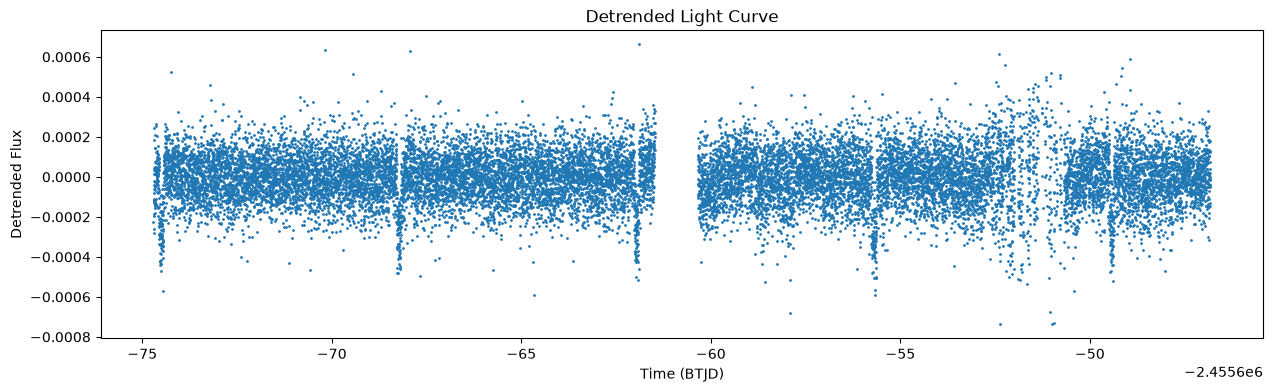

In [22]:
plt.figure(figsize=(15,4))
plt.scatter(result['time'], result['flux'], s=1)
plt.xlabel('Time (BTJD)')
plt.ylabel('Detrended Flux')
plt.title('Detrended Light Curve')
plt.show()

In [23]:
# ============================================================
# STAGE 1 OUTPUT EXPORT
# ============================================================

import pickle
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=False)

stage1_data = {
    "time": result['time'],
    "flux": result['flux'],
    "flux_err": result['flux_err'],

    # metadata now comes straight from the Stage 1 result dict
    "tic_id":   result.get("tic_id"),
    "crowdsap": result.get("crowdsap"),
    "ra":       result.get("ra"),
    "dec":      result.get("dec"),
    "sector":   result.get("sector"),
}

# sanity check so this never silently saves None again
if stage1_data["tic_id"] is None:
    print("[!] WARNING: tic_id is still None after extraction. "
          "Check raw_lc.meta keys, or set it manually before saving.")
else:
    print(f"Saving metadata -> TIC {stage1_data['tic_id']} | "
          f"RA/Dec {stage1_data['ra']}/{stage1_data['dec']} | "
          f"CROWDSAP {stage1_data['crowdsap']}")

save_path = os.path.join(DATA_DIR, "stage1_output.pkl")

with open(save_path, "wb") as f:
    pickle.dump(stage1_data, f)

print("Stage 1 data saved successfully!")
print(save_path)

[pipeline] mock drive.mount — using local repo
Saving metadata -> TIC 261136679 | RA/Dec 84.2911879979852/-80.4691197969941 | CROWDSAP 0.99965841
Stage 1 data saved successfully!
/content/drive/MyDrive/exoplanet_pipeline\data\stage1_output.pkl


In [24]:
# ============================================================
# OPTIONAL FAST REPAIR (self-contained) — patch stage1_output.pkl
# using raw_lc already in memory. No module reload needed.
# ============================================================
import pickle, os

pkl_path = os.path.join(DATA_DIR, "stage1_output.pkl")

def _extract_meta(lc, search_result=None, config=None):
    meta = getattr(lc, "meta", {}) or {}
    def _first(*keys):
        for k in keys:
            v = meta.get(k)
            if v is not None and str(v).strip().lower() not in ("", "none", "nan"):
                return v
        return None
    def _digits(s):
        d = "".join(ch for ch in str(s) if ch.isdigit())
        return int(d) if d else None

    tic_raw = _first("TICID", "TIC", "OBJECT", "KEPLERID")
    tic_id = _digits(tic_raw) if tic_raw is not None else None
    if tic_id is None and search_result is not None:
        try: tic_id = _digits(search_result.table["target_name"][0])
        except Exception: pass
    if tic_id is None and config is not None:
        tic_id = _digits(config.get("target", ""))

    ra  = _first("RA_OBJ", "RA");  ra  = float(ra)  if ra  is not None else None
    dec = _first("DEC_OBJ", "DEC"); dec = float(dec) if dec is not None else None
    cs  = _first("CROWDSAP");       cs  = float(cs)  if cs  is not None else None
    sec = _first("SECTOR");         sec = int(sec)   if sec is not None else None
    print(f"Metadata -> TIC {tic_id} | RA {ra} | Dec {dec} | CROWDSAP {cs} | Sector {sec}")
    return {"tic_id": tic_id, "ra": ra, "dec": dec, "crowdsap": cs, "sector": sec}

with open(pkl_path, "rb") as f:
    stage1_data = pickle.load(f)

meta = _extract_meta(
    raw_lc,
    search_result if "search_result" in dir() else None,
    PIPELINE_CONFIG,
)
stage1_data.update(meta)

with open(pkl_path, "wb") as f:
    pickle.dump(stage1_data, f)

print("Patched pkl saved ->", pkl_path)
print({k: stage1_data[k] for k in ("tic_id","ra","dec","crowdsap","sector")})

Metadata -> TIC 261136679 | RA 84.2911879979852 | Dec -80.4691197969941 | CROWDSAP 0.99965841 | Sector 1
Patched pkl saved -> /content/drive/MyDrive/exoplanet_pipeline\data\stage1_output.pkl
{'tic_id': 261136679, 'ra': 84.2911879979852, 'dec': -80.4691197969941, 'crowdsap': 0.99965841, 'sector': 1}
